<center>Universidade Federal de Viçosa</center>
<center>Coordenadoria de Educação Aberta e a Distância</center>
<center>Inteligência Artificial e Computacional</center>
<center>ELT578 - Análise de Imagens e Visão Computacional</center>

**<center>Desafio 3: Filtros passa-alta e passa baixa RGB</center>**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import cv2
from matplotlib import pyplot as plt
from google.colab.patches import cv2_imshow

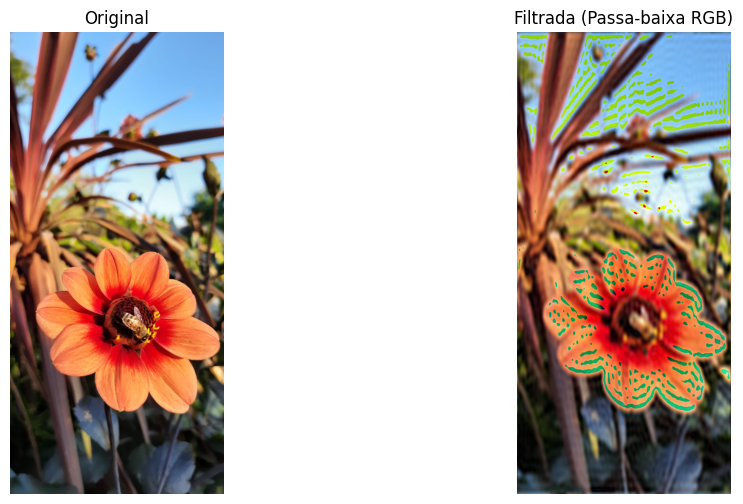

In [3]:
# Leitura da imagem colorida
img = cv2.imread('/content/drive/MyDrive/ELT578/SEMANA_2/flower.jpeg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # converte para RGB

# Parâmetros
rows, cols, ch = img.shape
crow, ccol = rows//2 , cols//2
r = 50  # raio do filtro passa-baixa

# Máscara circular
mask = np.zeros((rows, cols), np.uint8)
cv2.circle(mask, (ccol, crow), r, 1, -1)

# Lista para armazenar os canais filtrados
filtered_channels = []

for i in range(3):  # R, G, B
    channel = img[:,:,i]

    # FFT
    f = np.fft.fft2(channel)
    fshift = np.fft.fftshift(f)

    # Aplica o filtro
    fshift_filtered = fshift * mask

    # FFT inversa
    f_ishift = np.fft.ifftshift(fshift_filtered)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.abs(img_back)

    filtered_channels.append(img_back)

# Reconstrói a imagem colorida
img_filtered = cv2.merge(filtered_channels)

# Exibe
plt.figure(figsize=(12,6))
plt.subplot(121), plt.imshow(img)
plt.title('Original'), plt.axis('off')
plt.subplot(122), plt.imshow(np.uint8(img_filtered))
plt.title('Filtrada (Passa-baixa RGB)'), plt.axis('off')
plt.show()

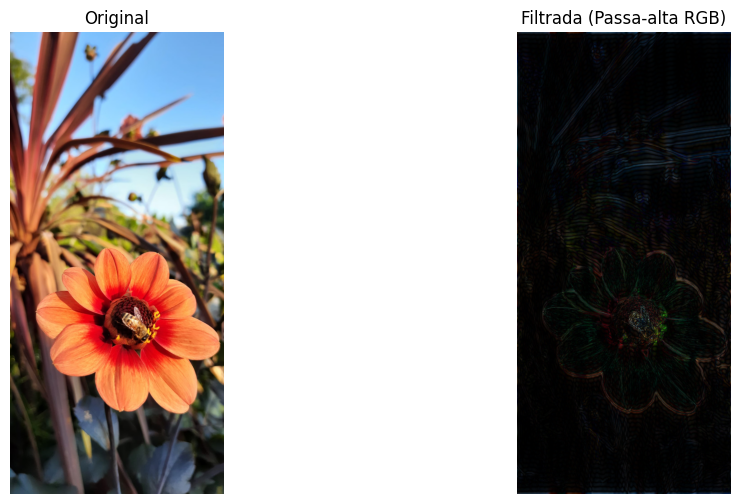

In [4]:
# Leitura da imagem colorida
img = cv2.imread('/content/drive/MyDrive/ELT578/SEMANA_2/flower.jpeg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # converte para RGB

# Parâmetros
rows, cols, ch = img.shape
crow, ccol = rows//2 , cols//2
r = 50  # raio da região que será removida (frequências baixas)

# Máscara passa-alta: zeros no centro, 1 nas bordas
mask = np.ones((rows, cols), np.uint8)
cv2.circle(mask, (ccol, crow), r, 0, -1)  # zera o círculo central

# Lista para armazenar os canais filtrados
filtered_channels = []

for i in range(3):  # R, G, B
    channel = img[:,:,i]

    # FFT
    f = np.fft.fft2(channel)
    fshift = np.fft.fftshift(f)

    # Aplica o filtro passa-alta
    fshift_filtered = fshift * mask

    # FFT inversa
    f_ishift = np.fft.ifftshift(fshift_filtered)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.abs(img_back)

    filtered_channels.append(img_back)

# Reconstrói a imagem colorida
img_filtered = cv2.merge(filtered_channels)

# Exibe
plt.figure(figsize=(12,6))
plt.subplot(121), plt.imshow(img)
plt.title('Original'), plt.axis('off')
plt.subplot(122), plt.imshow(np.uint8(img_filtered))
plt.title('Filtrada (Passa-alta RGB)'), plt.axis('off')
plt.show()